# Segment Events Budget Matrix Visualization

Heatmap of the budget matrix W = t_in - t_out, showing the free-window width per (pair, segment).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from pathlib import Path

import sys
sys.path.insert(0, '..')


from ksb.simulation.ksb_simulation import KSBSimulation

## Run simulation

In [2]:
# Load default config and adjust for visualization
config_path = Path("../configs/default.yaml")
with open(config_path) as f:
    cfg = yaml.safe_load(f)


print(f"Config: batch={cfg['batch']}, n_buffer_seg={cfg['n_buffer_seg']}")
print(f"Solver: {cfg.get('solver', 'scurve')}")

sim = KSBSimulation(cfg=cfg)
result = sim.run(seed=42)

W = result.segment_events.W
print(f"W shape: {W.shape}")
print(f"W range: [{W.min():.4f}, {W.max():.4f}]")

Config: batch=100, n_buffer_seg=6
Solver: quintic
W shape: (99, 6)
W range: [-0.1611, 0.2064]


## Heatmap: Budget Matrix W

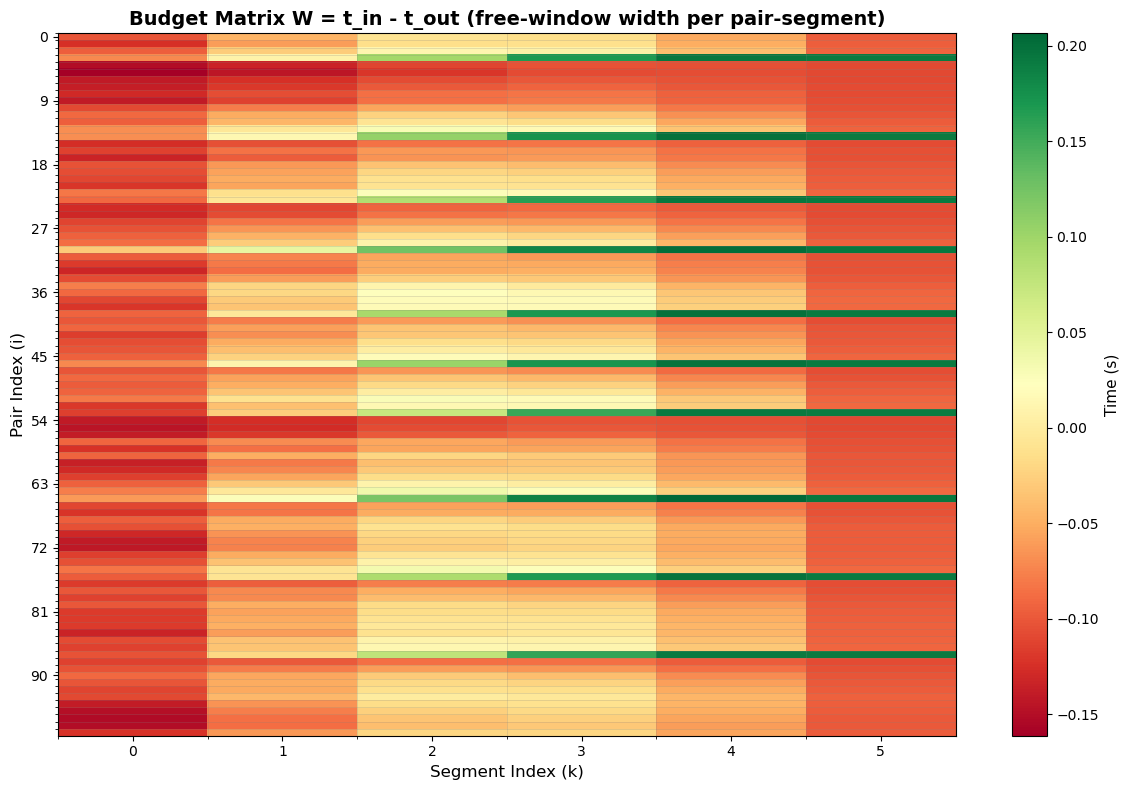

Heatmap saved to segment_events_W_heatmap.png


In [3]:
fig, ax = plt.subplots(figsize=(12, 8))

# Create heatmap
im = ax.imshow(W, cmap="RdYlGn", aspect="auto", interpolation="nearest")

# Labels and title
ax.set_xlabel("Segment Index (k)", fontsize=12)
ax.set_ylabel("Pair Index (i)", fontsize=12)
ax.set_title("Budget Matrix W = t_in - t_out (free-window width per pair-segment)", fontsize=14, fontweight="bold")

# Ticks
ax.set_xticks(np.arange(W.shape[1]))
ax.set_yticks(np.arange(0, W.shape[0], max(1, W.shape[0]//10)))  # Sparse y-ticks

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Time (s)", fontsize=11)

# Grid
ax.set_xticks(np.arange(W.shape[1]) - 0.5, minor=True)
ax.set_yticks(np.arange(W.shape[0]) - 0.5, minor=True)
ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.5, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Heatmap saved to segment_events_W_heatmap.png")

## Summary Statistics

In [4]:
print("Budget Matrix W Statistics")
print("="*50)
print(f"Shape: {W.shape} (pairs × segments)")
print(f"Min value: {W.min():.6f} s")
print(f"Max value: {W.max():.6f} s")
print(f"Mean value: {W.mean():.6f} s")
print(f"Std dev: {W.std():.6f} s")
print()
print(f"Negative values (inverted windows): {np.sum(W < 0)} / {W.size}")
print(f"Positive values (normal windows): {np.sum(W > 0)} / {W.size}")
print()
print("Per-segment averages:")
for k in range(W.shape[1]):
    print(f"  Segment {k}: mean={W[:, k].mean():.6f} s, min={W[:, k].min():.6f} s, max={W[:, k].max():.6f} s")

Budget Matrix W Statistics
Shape: (99, 6) (pairs × segments)
Min value: -0.161145 s
Max value: 0.206427 s
Mean value: -0.050764 s
Std dev: 0.071096 s

Negative values (inverted windows): 515 / 594
Positive values (normal windows): 79 / 594

Per-segment averages:
  Segment 0: mean=-0.109478 s, min=-0.161145 s, max=-0.029265 s
  Segment 1: mean=-0.057660 s, min=-0.142940 s, max=0.044173 s
  Segment 2: mean=-0.017869 s, min=-0.120608 s, max=0.125620 s
  Segment 3: mean=-0.012421 s, min=-0.107880 s, max=0.185910 s
  Segment 4: mean=-0.036960 s, min=-0.106283 s, max=0.206427 s
  Segment 5: mean=-0.070197 s, min=-0.109139 s, max=0.193531 s


## Per-Pair Profile

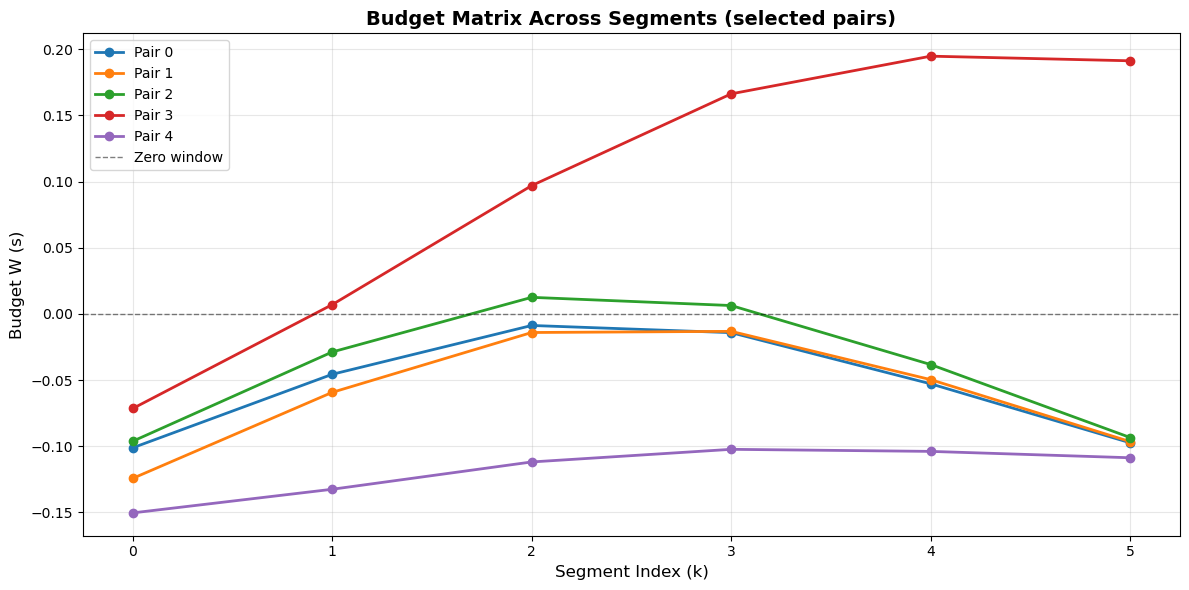

Profile plot saved to segment_events_W_profiles.png


In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot W[i, :] for each pair as a line
for i in range(min(5, W.shape[0])):  # First 5 pairs
    ax.plot(W[i, :], marker="o", label=f"Pair {i}", linewidth=2, markersize=6)

ax.axhline(y=0, color="k", linestyle="--", linewidth=1, alpha=0.5, label="Zero window")
ax.set_xlabel("Segment Index (k)", fontsize=12)
ax.set_ylabel("Budget W (s)", fontsize=12)
ax.set_title("Budget Matrix Across Segments (selected pairs)", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=10)

plt.tight_layout()
plt.show()

print(f"Profile plot saved to segment_events_W_profiles.png")

## Time Event Analysis

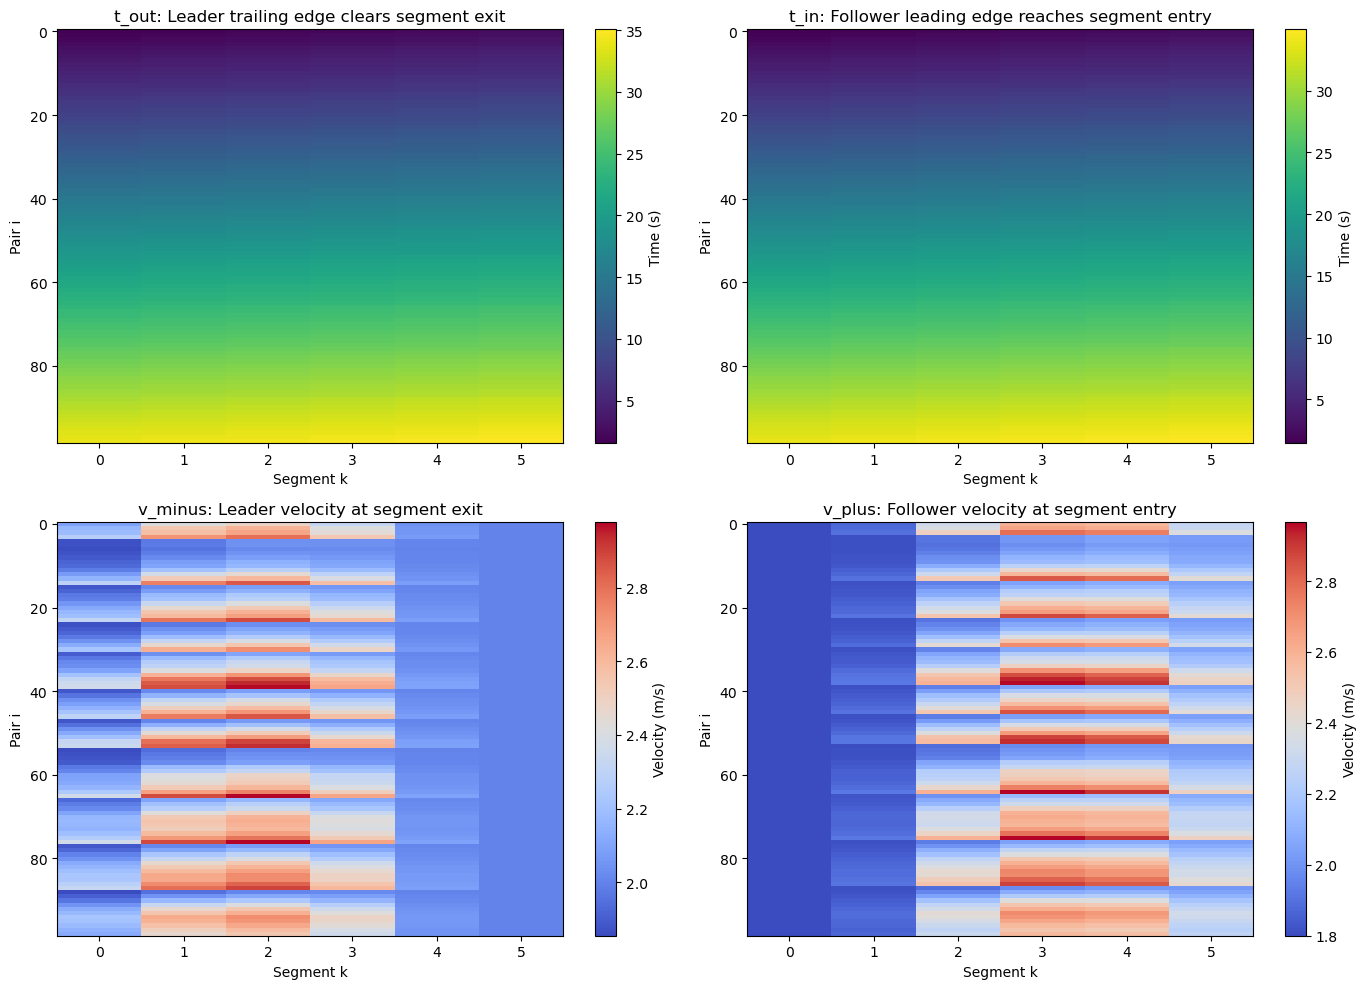

All event heatmaps saved to segment_events_all_heatmaps.png


In [6]:
t_out = result.segment_events.t_out
t_in = result.segment_events.t_in
v_minus = result.segment_events.v_minus
v_plus = result.segment_events.v_plus

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# t_out heatmap
im1 = axes[0, 0].imshow(t_out, cmap="viridis", aspect="auto")
axes[0, 0].set_title("t_out: Leader trailing edge clears segment exit")
axes[0, 0].set_xlabel("Segment k")
axes[0, 0].set_ylabel("Pair i")
plt.colorbar(im1, ax=axes[0, 0], label="Time (s)")

# t_in heatmap
im2 = axes[0, 1].imshow(t_in, cmap="viridis", aspect="auto")
axes[0, 1].set_title("t_in: Follower leading edge reaches segment entry")
axes[0, 1].set_xlabel("Segment k")
axes[0, 1].set_ylabel("Pair i")
plt.colorbar(im2, ax=axes[0, 1], label="Time (s)")

# v_minus heatmap
im3 = axes[1, 0].imshow(v_minus, cmap="coolwarm", aspect="auto")
axes[1, 0].set_title("v_minus: Leader velocity at segment exit")
axes[1, 0].set_xlabel("Segment k")
axes[1, 0].set_ylabel("Pair i")
plt.colorbar(im3, ax=axes[1, 0], label="Velocity (m/s)")

# v_plus heatmap
im4 = axes[1, 1].imshow(v_plus, cmap="coolwarm", aspect="auto")
axes[1, 1].set_title("v_plus: Follower velocity at segment entry")
axes[1, 1].set_xlabel("Segment k")
axes[1, 1].set_ylabel("Pair i")
plt.colorbar(im4, ax=axes[1, 1], label="Velocity (m/s)")

plt.tight_layout()
plt.show()

print("All event heatmaps saved to segment_events_all_heatmaps.png")